In [4]:
import torch
import torch.nn as nn
from torchvision import models
import copy
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import sys
sys.path.append('./dependencies')
# Import custom methods and architectures
from utils import *

# architeture

In [2]:
# Define the image processing network using ResNet18 as the backbone
class img_net(nn.Module):
    def __init__(self, img_fts=1):
        super(img_net, self).__init__()
        
        # Load pre-trained ResNet18 model and remove its fully connected layer
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Replace the final fully connected layer with a custom head (512 -> 128) followed by ReLU
        self.resnet.fc = nn.Sequential(
                nn.Linear(512, 128), # 128 latent representation
                nn.ReLU())
        
        # Classifier to output the desired number of features (img_fts)
        self.classifier = nn.Sequential(
            nn.Linear(128, img_fts), # Reduce the dimension from 128 to the number of image features
            nn.Sigmoid())  # Apply sigmoid to normalize the output to [0,1] range
        
    # Forward pass through the image processing network
    def forward(self, x, tab):
        x = self.resnet(x)  # Pass image through ResNet18 backbone
        x = self.classifier(x)  # Pass the features through the classifier
        return x
    
class ResBlock(nn.Module):
    """
    A two-convolutional layer residual block.
    """
    
    def __init__(self, c_in, c_out, k, s=1, p=1, mode='encode'):
        assert mode in ['encode', 'decode'], "Mode must be either 'encode' or 'decode'."
        super(ResBlock, self).__init__()
        if mode == 'encode':
            self.conv1 = nn.Conv2d(c_in, c_out, k, s, p)
            self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1)
        elif mode == 'decode':
            self.conv1 = nn.ConvTranspose2d(c_in, c_out, k, s, p)
            self.conv2 = nn.ConvTranspose2d(c_out, c_out, 3, 1, 1)
        self.relu = nn.ReLU()
        self.BN = nn.BatchNorm2d(c_out)
        self.resize = s > 1 or (s == 1 and p == 0) or c_out != c_in
    
    def forward(self, x):
        conv1 = self.BN(self.conv1(x))
        relu = self.relu(conv1)
        conv2 = self.BN(self.conv2(relu))
        if self.resize:
            x = self.BN(self.conv1(x))
        return self.relu(x + conv2)
    
class Decoder(nn.Module):
    """
    Decoder class, mainly consisting of two residual blocks.
    """
    
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(128,512),
            nn.ReLU(),
            nn.Linear(512,512*7*7),
            nn.ReLU(),
            nn.Unflatten(1, torch.Size([512,7,7]))
        )
        # 512x7x7 -> 3x200x200
        self.rb1 = ResBlock(512, 256, 3, 2, 0, 'decode')
        self.rb2 = ResBlock(256, 128, 3, 2, 0, 'decode')
        self.rb3 = ResBlock(128, 64, 5, 2, 0, 'decode')
        self.rb4 = ResBlock(64, 32, 5, 3, 0, 'decode')
        self.out_conv = nn.ConvTranspose2d(32, 3, 4, 1, 0)
        self.sig = nn.Sigmoid()
        self.deconv = nn.Sequential(
            self.rb1,
            self.rb2,
            self.rb3,
            self.rb4,
            self.out_conv,
            self.sig
        )
        
    def forward(self, x):
        x = self.fc(x)
        x = self.deconv(x)
        return x
    
class Autoencoder(nn.Module):
    """
    Autoencoder class, combines encoder and decoder model.
    """
    
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = img_net().resnet
        self.decoder = Decoder()
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [14]:
def show_images(original, reconstructed, n=5):
    """
    Displays `n` original and reconstructed image pairs using matplotlib.
    """
    original = original.cpu().detach().numpy()
    reconstructed = reconstructed.cpu().detach().numpy()
    
    fig, axs = plt.subplots(2, n, figsize=(n*2, 4))
    
    # Loop over n images to plot
    for i in range(n):
        # Original images
        axs[0, i].imshow(np.transpose(original[i], (1, 2, 0)))  # Reorder channels for imshow
        axs[0, i].axis('off')  # Turn off axes
        axs[0, i].set_title('Original')
        
        # Reconstructed images
        axs[1, i].imshow(np.transpose(reconstructed[i], (1, 2, 0)))
        axs[1, i].axis('off')
        axs[1, i].set_title('Reconstructed')

    plt.show()

In [ ]:
def train_ae(loader):
    DEVICE = torch.device('cuda:2') if torch.cuda.is_available() else torch.device('cpu')
    ae = Autoencoder().to(DEVICE)
    num_epochs = 100
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(ae.parameters(), lr=0.0001)

    for epoch in range(num_epochs):
        total_loss = 0.0

        for i, (img, _, _, _, _) in enumerate(loader):
            x = img.to(DEVICE, dtype=torch.float)
            out = ae(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        
        average_loss = total_loss / len(loader)
        print("___epoch ", epoch, ": MSE = ", average_loss)
        # Every 5 epochs, display 5 reconstructed images
        if (epoch + 1) == num_epochs:#% 5 == 0:
            # Select first 5 images from the last batch (or shuffle, your choice)
            show_images(x[:5], out[:5])
    model_wts = copy.deepcopy(ae.encoder.state_dict())

    return model_wts

def get_encoder(data, seed):
    """
    Train and save encoder weights for image feature enineering blocks

    Parameters:
        data: Dataset to be split into training and test sets
        seed: Random seed for reproducibility

    Returns:
        results: Updated DataFrame with new results
    """
    save_path = './models/img_encoders/'
    
    # Split data into training and testing folds
    for i, (train_idx, test_idx) in enumerate(split_data(data, seed)):
        print("Training Fold #", str(i))
        train_loader, val_loader, test_loader = get_dataloaders(data, train_idx, test_idx, seed)
        encoder_wts = train_ae(train_loader)  # Train the model
        #filename = 'img_encoder_' + str(i) + '.pth'
        #torch.save(encoder_wts, save_path + filename)
        #print("-> saved model #", str(i))

In [ ]:
# Here it doesn't matter the label since it's unsupervised learning
labels = pd.read_csv(DATA_DIR + 'fusion_labels.csv')
# The tabular data is not used but we need it to build the dataset
tab = pd.read_csv(DATA_DIR + '/tab_data.csv')
tab.drop(columns=['A', 'B', 'C', 'id'], inplace=True)
# Combine the tabular data and labels into a single DataFrame for training
data = pd.concat([tab, labels], axis=1)

Starting autoencoder training
Training Fold # 0


___epoch  0 : MSE =  0.20000876858830452
___epoch  1 : MSE =  0.12982573583722115
___epoch  2 : MSE =  0.10786981135606766
___epoch  3 : MSE =  0.09803813323378563
___epoch  4 : MSE =  0.09249843806028366
___epoch  5 : MSE =  0.0893508654087782
___epoch  6 : MSE =  0.08511761911213397
___epoch  7 : MSE =  0.08145077750086785
___epoch  8 : MSE =  0.07792972847819328
___epoch  9 : MSE =  0.07601262889802456
___epoch  10 : MSE =  0.07477454170584678
___epoch  11 : MSE =  0.07439431250095367
___epoch  12 : MSE =  0.07326003611087799
___epoch  13 : MSE =  0.07279777489602565
___epoch  14 : MSE =  0.07186336033046245
___epoch  15 : MSE =  0.07138566859066486
___epoch  16 : MSE =  0.07070586383342743
___epoch  17 : MSE =  0.07065038420259953
___epoch  18 : MSE =  0.07019067518413066
___epoch  19 : MSE =  0.06993473023176193
___epoch  20 : MSE =  0.06974015012383461
___epoch  21 : MSE =  0.06964174434542655
___epoch  22 : MSE =  0.06943259686231613
___epoch  23 : MSE =  0.06908683404326439
___

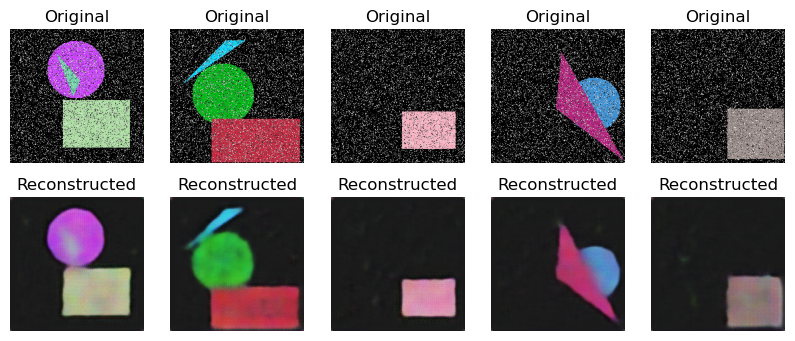

Training Fold # 1
___epoch  0 : MSE =  0.1509702406823635
___epoch  1 : MSE =  0.09245582371950149
___epoch  2 : MSE =  0.08491569273173809
___epoch  3 : MSE =  0.0810839656740427
___epoch  4 : MSE =  0.07805018685758114
___epoch  5 : MSE =  0.07549584396183491
___epoch  6 : MSE =  0.07367147915065289
___epoch  7 : MSE =  0.07303265668451786
___epoch  8 : MSE =  0.07197303995490074
___epoch  9 : MSE =  0.07159320972859859
___epoch  10 : MSE =  0.07087035514414311
___epoch  11 : MSE =  0.07045193761587143
___epoch  12 : MSE =  0.0703981053084135
___epoch  13 : MSE =  0.06992835067212581
___epoch  14 : MSE =  0.06970606446266174
___epoch  15 : MSE =  0.06953082010149955
___epoch  16 : MSE =  0.06914586909115314
___epoch  17 : MSE =  0.06899778805673122
___epoch  18 : MSE =  0.06887411661446094
___epoch  19 : MSE =  0.0685081884264946
___epoch  20 : MSE =  0.06842242255806923
___epoch  21 : MSE =  0.0684394422918558
___epoch  22 : MSE =  0.06833361387252808
___epoch  23 : MSE =  0.0677410

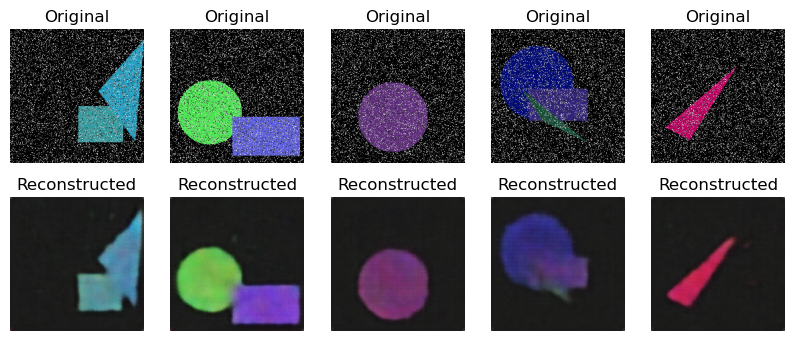

Training Fold # 2
___epoch  0 : MSE =  0.2078537203371525
___epoch  1 : MSE =  0.13384790308773517
___epoch  2 : MSE =  0.10455466024577617
___epoch  3 : MSE =  0.09400474950671196
___epoch  4 : MSE =  0.08889330103993416
___epoch  5 : MSE =  0.08537592999637127
___epoch  6 : MSE =  0.08263243287801743
___epoch  7 : MSE =  0.07976049482822418
___epoch  8 : MSE =  0.07709931805729867
___epoch  9 : MSE =  0.0754047479480505
___epoch  10 : MSE =  0.07412491999566555
___epoch  11 : MSE =  0.07328103855252266
___epoch  12 : MSE =  0.07242676466703415
___epoch  13 : MSE =  0.07194563746452332
___epoch  14 : MSE =  0.07188787311315536
___epoch  15 : MSE =  0.07160832211375237
___epoch  16 : MSE =  0.07128737047314644
___epoch  17 : MSE =  0.07074854075908661
___epoch  18 : MSE =  0.07053317725658417
___epoch  19 : MSE =  0.07050660252571106
___epoch  20 : MSE =  0.07004866003990173
___epoch  21 : MSE =  0.06952199414372444
___epoch  22 : MSE =  0.06944594644010067
___epoch  23 : MSE =  0.0693

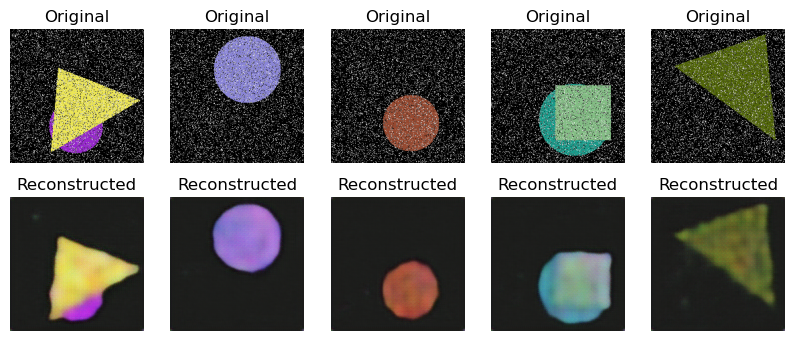

Training Fold # 3
___epoch  0 : MSE =  0.14749264307320117
___epoch  1 : MSE =  0.0966083437204361
___epoch  2 : MSE =  0.08647208996117114
___epoch  3 : MSE =  0.08223112709820271
___epoch  4 : MSE =  0.07969971522688865
___epoch  5 : MSE =  0.07705735005438327
___epoch  6 : MSE =  0.07515158280730247
___epoch  7 : MSE =  0.07392900474369526
___epoch  8 : MSE =  0.07281460762023925
___epoch  9 : MSE =  0.07227760180830956
___epoch  10 : MSE =  0.07195137701928615
___epoch  11 : MSE =  0.07145617082715035
___epoch  12 : MSE =  0.07090886943042278
___epoch  13 : MSE =  0.07066069431602955
___epoch  14 : MSE =  0.07020602934062481
___epoch  15 : MSE =  0.0703633300960064
___epoch  16 : MSE =  0.06979246139526367
___epoch  17 : MSE =  0.06965425312519073
___epoch  18 : MSE =  0.06940754987299443
___epoch  19 : MSE =  0.06921903751790523
___epoch  20 : MSE =  0.06926276236772537
___epoch  21 : MSE =  0.0690846849232912
___epoch  22 : MSE =  0.06879272498190403
___epoch  23 : MSE =  0.06839

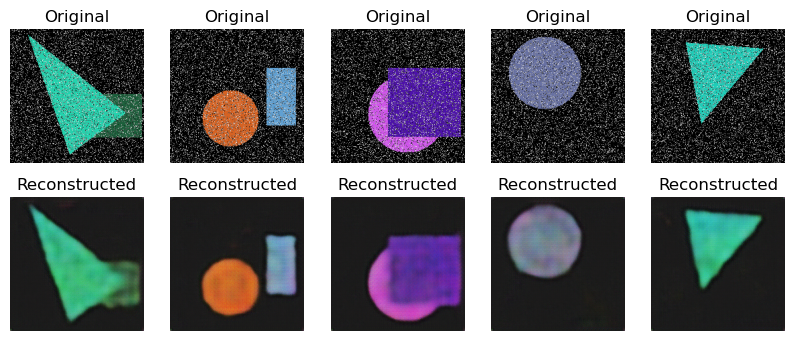

Training Fold # 4
___epoch  0 : MSE =  0.15278785973787307
___epoch  1 : MSE =  0.10029437914490699
___epoch  2 : MSE =  0.08931367062032222
___epoch  3 : MSE =  0.08506857976317406
___epoch  4 : MSE =  0.08186011090874672
___epoch  5 : MSE =  0.07903170436620713
___epoch  6 : MSE =  0.07607830241322518
___epoch  7 : MSE =  0.07420420050621032
___epoch  8 : MSE =  0.0735151082277298
___epoch  9 : MSE =  0.07224297299981117
___epoch  10 : MSE =  0.07161761224269866
___epoch  11 : MSE =  0.07132809311151504
___epoch  12 : MSE =  0.0709066990762949
___epoch  13 : MSE =  0.07054269947111606
___epoch  14 : MSE =  0.07043244838714599
___epoch  15 : MSE =  0.07000196278095246
___epoch  16 : MSE =  0.06961971968412399
___epoch  17 : MSE =  0.06954120211303234
___epoch  18 : MSE =  0.06936121471226216
___epoch  19 : MSE =  0.06926954574882985
___epoch  20 : MSE =  0.06886472813785076
___epoch  21 : MSE =  0.06872493512928486
___epoch  22 : MSE =  0.0686814334243536
___epoch  23 : MSE =  0.06818

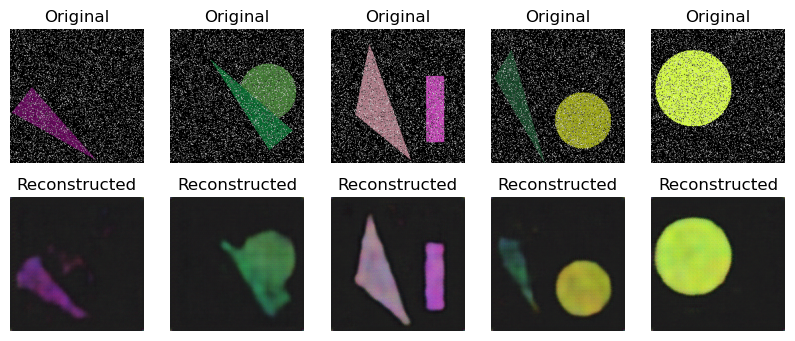

In [35]:
SEED = 0
set_seed(SEED) # Set the random seed for reproducibility
print("Starting autoencoder training")
get_encoder(data, SEED)